# Performance Analytics for Mutual Funds

This notebook computes daily returns, CAGR, Sharpe, Sortino, alpha/beta, maximum drawdown, and the fund scorecard for the 40 schemes in the dataset. It also generates a benchmark comparison chart for the top 5 funds over the past 3 years.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.performance_analytics import (
    load_data,
    compute_daily_returns,
    compute_cagr,
    compute_sharpe_sortino,
    compute_alpha_beta,
    compute_max_drawdown,
    build_scorecard,
    benchmark_tracking_error,
)

%matplotlib inline

fund_master, nav, benchmark = load_data()
nav = nav.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
nav_returns = compute_daily_returns(nav)

In [2]:
# 1. Daily return distribution check
returns = nav_returns['daily_return'].dropna()
returns.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(6)

count    52058.000000
mean         0.308054
std          5.707833
min         -0.992572
1%          -0.319778
5%          -0.020683
25%         -0.004046
50%          0.000486
75%          0.006574
95%          0.029220
99%          0.498346
max        131.828188
Name: daily_return, dtype: float64

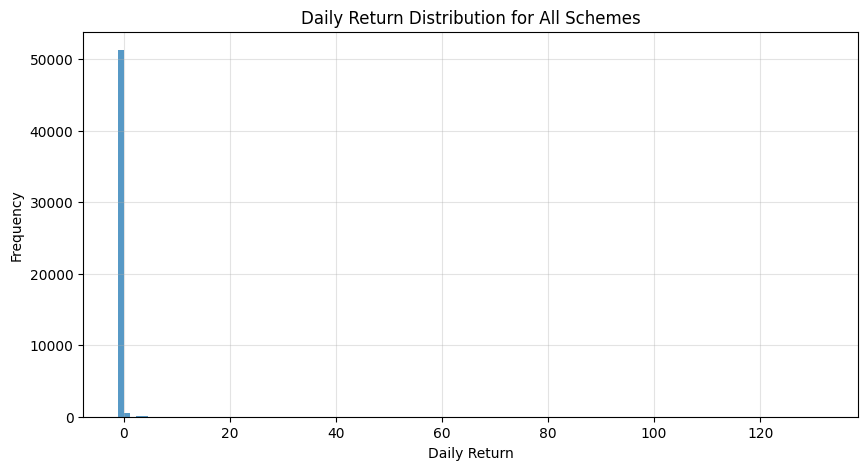

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(returns, bins=120, color='#1f77b4', alpha=0.75)
plt.title('Daily Return Distribution for All Schemes')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(alpha=0.35)
plt.show()

In [4]:
# 2. Compute performance metrics and scorecard
cagr_df = compute_cagr(nav)
risk_df = compute_sharpe_sortino(nav_returns)
alpha_beta_df = compute_alpha_beta(nav_returns, benchmark)
max_dd_df = compute_max_drawdown(nav)

performance = (
    cagr_df
    .merge(risk_df[['amfi_code', 'sharpe_ratio', 'sortino_ratio']], on='amfi_code')
    .merge(alpha_beta_df[['amfi_code', 'alpha_ann', 'beta']], on='amfi_code')
    .merge(max_dd_df[['amfi_code', 'max_drawdown_pct', 'drawdown_peak_date', 'drawdown_trough_date']], on='amfi_code')
)
performance[['cagr_1yr_pct', 'cagr_3yr_pct', 'cagr_5yr_pct']] = performance[['cagr_1yr', 'cagr_3yr', 'cagr_5yr']] * 100
performance = performance.drop(columns=['cagr_1yr', 'cagr_3yr', 'cagr_5yr'])
performance = performance.rename(columns={'alpha_ann': 'alpha_ann'})

scorecard = build_scorecard(performance, fund_master)
scorecard['alpha_annual_pct'] = scorecard['alpha_ann'] * 100
scorecard.head(10)


,amfi_code,sharpe_ratio,sortino_ratio,alpha_ann,beta,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date,cagr_1yr_pct,cagr_3yr_pct,...,rank_expense_ratio,rank_max_drawdown,score_3yr_return,score_sharpe,score_alpha,score_expense,score_max_drawdown,fund_score,fund_score_rank,alpha_annual_pct
0,125497,3.366311,11.876357,83.084272,-0.838848,-86.405462,2026-04-17,2026-07-04,2.746775,13.565192,...,14.0,2.0,16.153846,24.358974,19.487179,10.000000,9.743590,79.74,1,8308.427220
1,100033,1.195179,1.936852,0.272375,-0.007974,-16.217209,2022-03-11,2022-05-12,25.965837,28.988468,...,16.0,25.0,28.461538,20.512821,16.410256,9.230769,3.846154,78.46,2,27.237519
2,149324,0.911513,1.470189,0.272865,0.029148,-31.171900,2024-05-03,2025-01-03,14.852093,30.041690,...,26.0,10.0,29.230769,16.025641,16.923077,5.384615,7.692308,75.26,3,27.286528
3,120841,1.929253,2.961098,10.353041,-0.097622,-64.997895,2023-11-15,2023-12-04,-0.547639,17.886260,...,35.0,4.0,21.538462,23.076923,18.974359,1.923077,9.230769,74.74,4,1035.304085
4,118632,1.538792,1.868377,1.140521,-0.320231,-40.452828,2014-04-12,2014-05-02,-0.740783,15.374024,...,24.0,8.0,18.461538,22.435897,17.948718,6.153846,8.205128,73.21,5,114.052095
5,120505,1.072378,1.722429,0.256573,-0.029876,-18.188514,2024-10-24,2025-01-23,24.475445,18.821413,...,15.0,22.0,22.307692,19.230769,15.897436,9.615385,4.615385,71.67,6,25.657336
6,119094,0.988283,1.580799,0.244410,-0.053677,-20.960884,2022-04-14,2022-08-11,-2.225065,24.122663,...,16.0,19.0,25.384615,16.666667,14.871795,9.230769,5.384615,71.54,7,24.440998
7,148567,1.075870,1.613050,0.197832,0.028315,-11.265729,2023-07-11,2023-10-20,-0.701859,33.281947,...,23.0,33.0,30.000000,19.871795,12.307692,6.538462,1.794872,70.51,8,19.783239
8,120843,1.240800,2.095882,0.241845,-0.024690,-12.973968,2022-03-07,2022-04-13,-2.183088,23.714049,...,22.0,28.0,24.615385,21.153846,14.358974,6.923077,3.076923,70.13,9,24.184493
9,120503,1.954009,2.456422,0.577902,-0.228138,-42.287631,2014-04-12,2014-05-02,-2.683634,11.670225,...,20.0,7.0,12.307692,23.717949,17.435897,7.692308,8.461538,69.62,10,57.790185


In [5]:
# 3. Save requested deliverables
scorecard = scorecard.drop(columns=['alpha_ann'])
scorecard.to_csv('fund_scorecard.csv', index=False)
alpha_beta_out = alpha_beta_df.merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left'
)
alpha_beta_out['alpha_annual_pct'] = alpha_beta_out['alpha_ann'] * 100
alpha_beta_out = alpha_beta_out[['amfi_code', 'scheme_name', 'fund_house', 'alpha_annual_pct', 'beta', 'r_value', 'p_value', 'stderr', 'n_obs']]
alpha_beta_out.to_csv('alpha_beta.csv', index=False)

print('Saved fund_scorecard.csv and alpha_beta.csv')
scorecard[['amfi_code', 'scheme_name', 'fund_score', 'rank_3yr_return', 'rank_sharpe', 'rank_alpha', 'rank_expense_ratio', 'rank_max_drawdown']].head(10)


Saved fund_scorecard.csv and alpha_beta.csv


,amfi_code,scheme_name,fund_score,rank_3yr_return,rank_sharpe,rank_alpha,rank_expense_ratio,rank_max_drawdown
0,125497,HDFC Top 100 Fund - Direct Plan - Growth,79.74,19.0,2.0,2.0,14.0,2.0
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,78.46,3.0,8.0,8.0,16.0,25.0
2,149324,DSP Small Cap Fund - Regular - Growth,75.26,2.0,15.0,7.0,26.0,10.0
3,120841,Kotak Bluechip Fund - Regular - Growth,74.74,12.0,4.0,3.0,35.0,4.0
4,118632,Nippon India Large Cap Fund - Regular - Growth,73.21,16.0,5.0,5.0,24.0,8.0
5,120505,ICICI Pru Midcap Fund - Regular - Growth,71.67,11.0,10.0,9.0,15.0,22.0
6,119094,Axis Midcap Fund - Regular - Growth,71.54,7.0,14.0,11.0,16.0,19.0
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,70.51,1.0,9.0,16.0,23.0,33.0
8,120843,Kotak Flexicap Fund - Regular - Growth,70.13,8.0,7.0,12.0,22.0,28.0
9,120503,ICICI Pru Bluechip Fund - Regular - Growth,69.62,24.0,3.0,6.0,20.0,7.0


In [6]:
# 4. Benchmark comparison chart and tracking error for top 5 funds
top5 = scorecard.head(5)['amfi_code'].tolist()
tracking = benchmark_tracking_error(nav_returns, benchmark, top5)
tracking['tracking_error_pct'] = tracking['tracking_error'] * 100
tracking.sort_values(['index_name', 'tracking_error']).head(10)

,amfi_code,index_name,tracking_error,n_obs,tracking_error_pct
6,100033,NIFTY100,0.206666,1148,20.666590
7,149324,NIFTY100,0.253225,1148,25.322521
9,118632,NIFTY100,1.315325,1291,131.532456
8,120841,NIFTY100,4.902328,1291,490.232822
5,125497,NIFTY100,19.982226,1291,1998.222569
1,100033,NIFTY50,0.208420,1148,20.842023
2,149324,NIFTY50,0.249966,1148,24.996591
4,118632,NIFTY50,1.308205,1291,130.820503
3,120841,NIFTY50,4.898964,1291,489.896398
0,125497,NIFTY50,19.978050,1291,1997.805042


The benchmark comparison chart has been saved to `reports/charts/benchmark_comparison_top5.png`. The tracker computes the annualized return volatility of the active return versus the index.

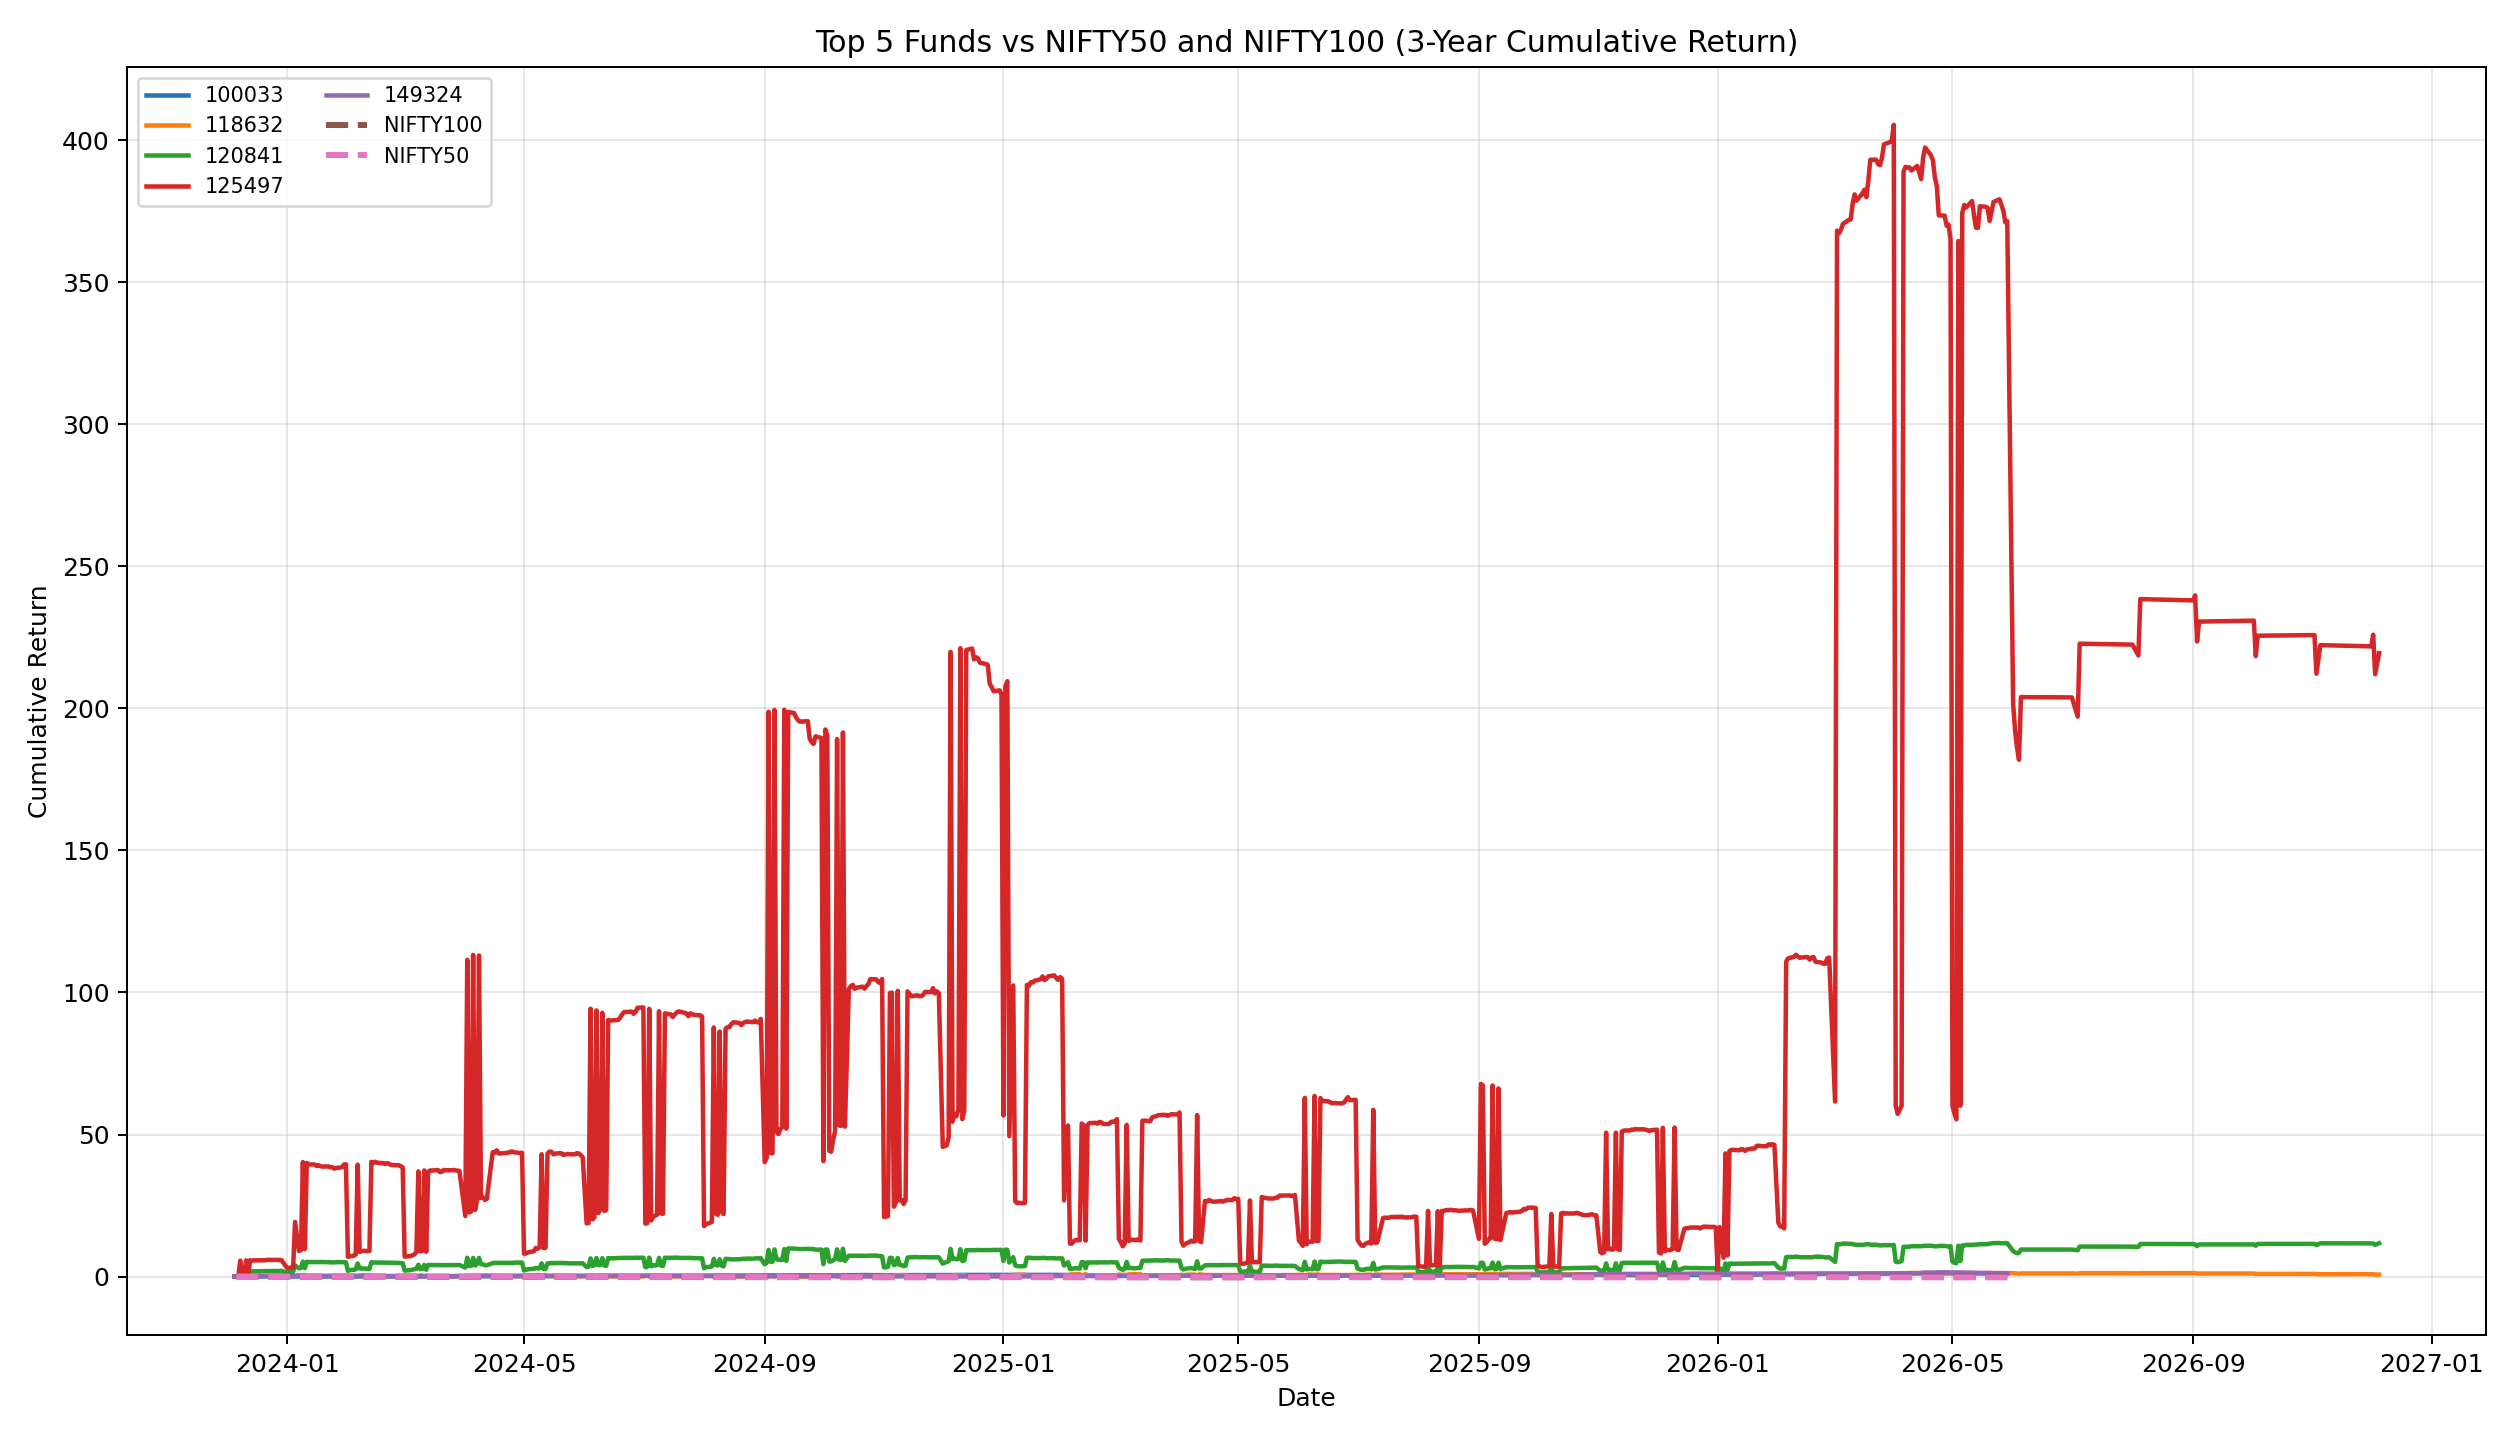

In [7]:
from IPython.display import Image, display
display(Image(filename='reports/charts/benchmark_comparison_top5.png'))